In [2]:
%load_ext autoreload
%autoreload 2

import sys, os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
from torch import nn
import wandb
import torchvision
from tqdm import tqdm
import torch.nn.functional as F 

sys.path.append(os.path.join(os.getcwd(), '../symlie'))
sys.path.append(os.path.join(os.getcwd(), '../'))

from symlie.model.networks.mlp import CombiMLP
from symlie.model.learner import CombiLearner
from symlie.misc.viz import wb_plot_pred
from symlie.run import parse_options, main, process_args, generate_data

/Users/elias/anaconda3/envs/sympde/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
args = parse_options(notebook=True)
args.config = 'combi'
args.do_return = True
# args.logger = None

args.lossweight_o = 1.
args.lossweight_y = 1. 

args.pretrained = False
args.optimizer_setting = 'multi'

process_args(args)

# Training
model, trainer, datamodule = main(args)
# generate_data(args)

Seed set to 1
Failed to detect the name of this notebook, you can set it manually with the WANDB_NOTEBOOK_NAME environment variable to enable code saving.


Init rng


wandb: Currently logged in as: eliasdubbeldam. Use `wandb login --relogin` to force relogin


/Users/elias/anaconda3/envs/sympde/lib/python3.10/site-packages/pytorch_lightning/loggers/wandb.py:389: There is a wandb run already in progress and newly created instances of `WandbLogger` will reuse this run. If this is not desired, call `wandb.finish()` before instantiating `WandbLogger`.
/Users/elias/anaconda3/envs/sympde/lib/python3.10/site-packages/pytorch_lightning/trainer/setup.py:187: GPU available but not used. You can set it by doing `Trainer(accelerator='gpu')`.


Running upbeat-universe-3272 with id pp8477a2


wandb: WARNING Source type is set to 'repo' but some required information is missing from the environment. A job will not be created from this run. See https://docs.wandb.ai/guides/launch/create-job


In [4]:
batch = next(iter(datamodule.train_dataloader()))

In [8]:
out = model(batch)

In [16]:
model.step(batch, mode = 'val')

RuntimeError: CombiLearner is not attached to a `Trainer`.

In [14]:
len(out[0]), len(out[1]), len(out[2])

(2, 2, 2)

In [ ]:
torch.save(model.net.implicit_layers[0].implicit_layer.state_dict(), 'implicit_layer0.pt')
torch.save(model.net.implicit_layers[1].implicit_layer.state_dict(), 'implicit_layer1.pt')

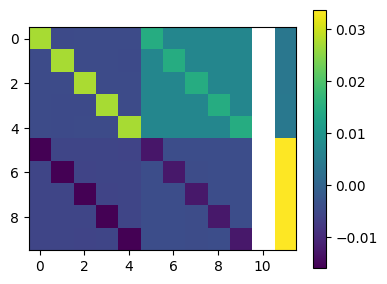

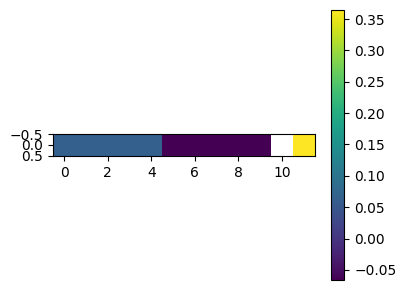

In [4]:
def plot_layer(layer_idx: int, bias: bool, randn: bool):
    
    if randn:
        w_in = torch.randn(model.net.vanilla_layers[layer_idx].weight.data.shape)
        b_in = torch.randn(model.net.vanilla_layers[layer_idx].bias.data.shape) if bias else None
    else:
        w_in = model.net.vanilla_layers[layer_idx].weight.data.clone()
        b_in = model.net.vanilla_layers[layer_idx].bias.data.clone() if bias else None

    w_out, b_out = model.net.implicit_layers[layer_idx](w_in, b_in)


    wb_plot_pred(w_out, b_out)


for layer_idx in range(2):
    plot_layer(layer_idx, bias=True, randn=False)

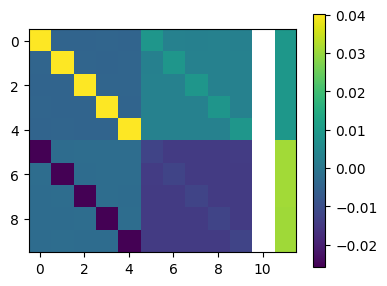

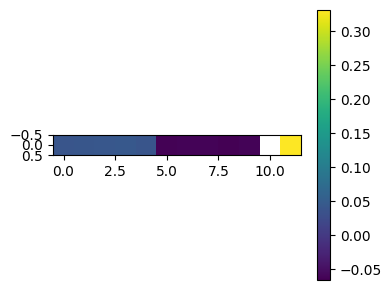

In [3]:
def plot_layer(layer_idx: int, bias: bool, randn: bool):
    
    if randn:
        w_in = torch.randn(model.net.vanilla_layers[layer_idx].weight.data.shape)
        b_in = torch.randn(model.net.vanilla_layers[layer_idx].bias.data.shape) if bias else None
    else:
        w_in = model.net.vanilla_layers[layer_idx].weight.data.clone()
        b_in = model.net.vanilla_layers[layer_idx].bias.data.clone() if bias else None

    w_out, b_out = model.net.implicit_layers[layer_idx](w_in, b_in)


    wb_plot_pred(w_out, b_out)


for layer_idx in range(2):
    plot_layer(layer_idx, bias=True, randn=False)


    


